# Bayesian MDP Planning with JAX.

In this advanced notebook, we show how Bayesian MDP formulations allow us to solve Bayesian bandit problems with JaxPlan.

In a classic multi-armed bandit, we have $N$ arms, each arm $i$ has unknown success probability of $\theta_i \in [0, 1]$. 
In each decision epoch, we decide which arm $a_t$ to pull, then generate an outcome $o_t \sim Bernoulli(\theta_{a_t})$.
The ultimate goal is to maintain a belief over the unknown success probabilities $\lbrace \theta_i \rbrace$ while also deciding upon the optimal sequence of actions $a_0, a_1 \dots a_T$.

It is not hard to show that the conjugate prior for each arm's $\theta_i$ is a $Beta(\alpha_i, \beta_i)$ distribution.
In other words, if we pull arm $i$ at epoch $t$, we observe $o_t \sim Bernoulli(\theta_{i})$, thus the posterior update is:
\begin{align}
    \alpha_i' &= \alpha_i + o_t, \\
    \beta_i' &= \beta_i + (1 - o_t).
\end{align}

The key insight is that the posterior parameters $(\alpha_i, \beta_i)$ for each arm are sufficient statistics for the entire history of observations. 
In other words, once you know $(\alpha_i, \beta_i)$, you do not need to remember which outcomes happened or when they happened -- the posterior fully summarizes everything that is relevant for deciding on $a_t$.
Therefore, the problem can be formulated as an fully observed MDP with the state represented by $\lbrace (\alpha_i, \beta_i) \rbrace$, and state transitions determined by the equations above.

We solve this MDP using JaxPlan and compare it to the classical UCB solution.


First, install the required packages:

In [2]:
%pip install --quiet --upgrade pip
%pip install --quiet scipy pyRDDLGym rddlrepository

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import the required packages:

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta

import pyRDDLGym
from pyRDDLGym.core.policy import BaseAgent
from pyRDDLGym_jax.core.planner import JaxBackpropPlanner, JaxOfflineController, load_config_from_string

We will load the Bernoulli bandit MDP, which is a fully observed MDP whose state is the sufficient statistic:

In [4]:
env = pyRDDLGym.make('BernoulliBandit', '0', vectorized=True)

This problem has 6 arms. Let's see what the true parameters $\theta_i$ look like:

In [5]:
thetas = env.model.non_fluents['TRUE_THETA']
print(thetas)

[0.1, 0.2, 0.8, 0.9, 0.2, 0.3]


Let's solve this problem using the JaxPlan DRP:

In [6]:
config = """
[Compiler]
[Planner]
method='JaxDeepReactivePolicy'
method_kwargs={'topology': [16, 16]}
optimizer_kwargs={'learning_rate': 0.0001}
[Optimize]
key=42
"""
planner_args, _, train_args = load_config_from_string(config)
planner = JaxBackpropPlanner(rddl=env.model, **planner_args)
jaxplan = JaxOfflineController(planner, print_summary=False, train_seconds=20, **train_args)

[INFO] Compiler will cast pvars {'outcome', 'pull'} to float.
[INFO] Compiler will cast CPFs {'outcome'} to float.
[INFO] Bounds of action-fluent <pull> set to (None, None).


 1160 it |      26.84375 train |      27.04375 test |      26.93438 [48 it] pgpe |      27.23438 best | 5 status: 100%|██████████| 00:18 , 58.04it/s


Recall, that the state contains all sufficient statistics for the posterior. Thus, plotting the state tells us how the belief evolves over the decision horizon:

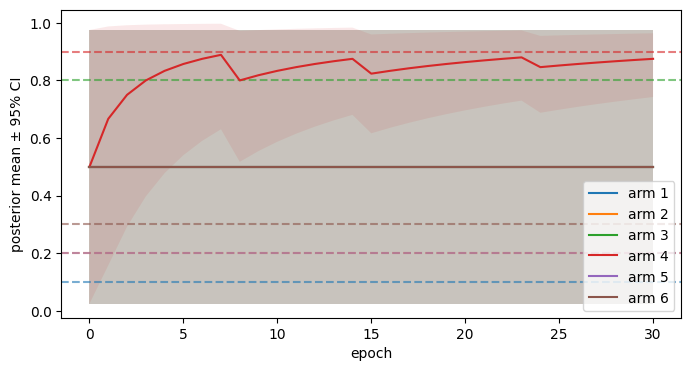

In [7]:
# collect state history
def plot_posterior_evolution(agent):
    agent.reset()
    state, _ = env.reset()
    states = [state]
    for _ in range(env.horizon):
        action = agent.sample_action(state)
        state, *_ = env.step(action)
        states.append(state)

    # calculate mean alpha_ i / (alpha_i + beta_i) and 95% CI
    T = len(states)
    K = states[0]["alpha"].shape[0]
    means = np.zeros((T, K))
    lowers = np.zeros((T, K))
    uppers = np.zeros((T, K))
    for t, s in enumerate(states):
        a, b = s["alpha"], s["beta"]
        means[t] = a / (a + b)
        lowers[t] = beta.ppf(0.025, a, b)
        uppers[t] = beta.ppf(0.975, a, b)

    # plot these values
    %matplotlib inline
    plt.figure(figsize=(8, 4))
    for i in range(K):
        line, = plt.plot(np.arange(T), means[:, i], label=f"arm {i + 1}")
        plt.fill_between(np.arange(T), lowers[:, i], uppers[:, i], alpha=0.1)
        plt.axhline(thetas[i], linestyle="--", color=line.get_color(), alpha=0.6)
    plt.xlabel("epoch")
    plt.ylabel("posterior mean ± 95% CI")
    plt.legend()
    plt.show()
plot_posterior_evolution(jaxplan)

Let's write a UCB baseline to help compare results: 

In [12]:
class UCB(BaseAgent):

    def __init__(self, c=1.0):
        self.c = c

    def sample_action(self, state):
        alpha = state["alpha"]
        beta  = state["beta"]
        n = alpha + beta - 2.0  # successes + failures
        n = np.maximum(n, 1e-8)
        mu = (alpha - 1.0) / n
        N = np.sum(n)
        bonus = self.c * np.sqrt(2.0 * np.log(N + 1.0) / n)
        ucb = mu + bonus
        pull = np.zeros((len(alpha),), dtype=np.bool_)
        pull[np.argmax(ucb)] = True
        return {'pull': pull}

Let's plot the posterior evolution to compare with JaxPlan:

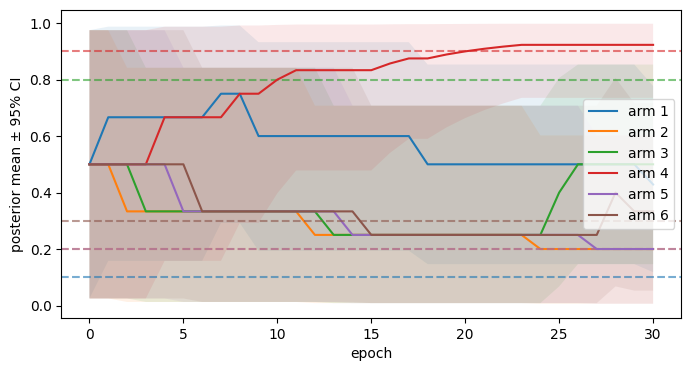

In [13]:
baseline = UCB()
plot_posterior_evolution(baseline)

A useful metric is regret, that is, how many times each method pulls the wrong arm:

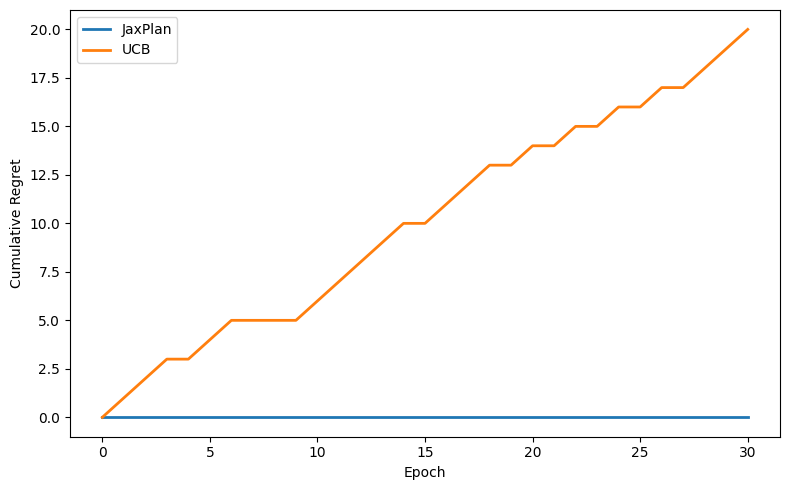

In [14]:
# calculate regret of both methods
def compute_regret(agent):
    agent.reset()
    state, _ = env.reset()
    regrets = [0]
    for _ in range(env.horizon):
        action = agent.sample_action(state)
        state, *_ = env.step(action)
        correct_arm = action['pull'][np.argmax(thetas)]
        regrets.append(regrets[-1] + (1 - correct_arm))
    return np.array(regrets)
regret_jaxplan = compute_regret(jaxplan)
regret_ucb = compute_regret(baseline)

# plot regret side by side
%matplotlib inline
plt.figure(figsize=(8, 5))
xs = np.arange(len(regret_jaxplan))
plt.plot(xs, regret_jaxplan, label="JaxPlan", linewidth=2)
plt.plot(xs, regret_ucb, label="UCB", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cumulative Regret")
plt.legend()
plt.tight_layout()
plt.show()


We see that the Bayesian MDP formulation allows for optimal reasoning and uncertainty allocation in a small horizon.